## Imports et connexion

In [1]:
import os
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import librosa

In [2]:
load_dotenv(dotenv_path="../.env")

conn = psycopg2.connect(
    host="localhost",
    port="5432",
    database="datapulse_db",
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD")
)

query = """
SELECT t.filename, t.source_dataset, t.size_bytes, t.duration_seconds, i.label_name as instrument
FROM audio_tracks t
JOIN instruments i ON t.instrument_id = i.id;
"""
df = pd.read_sql(query, conn)
conn.close()


df['size_mb'] = df['size_bytes'] / (1024 * 1024)
print(f"{len(df)} pistes chargées avec succès depuis PostgreSQL Gold !")

23262 pistes chargées avec succès depuis PostgreSQL Gold !


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_10916\903065394.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


## Analyses statistiques (C2.1 & 2.2)

### Recherche des valeurs manquantes

In [3]:
def analyse_missing_data(df) :
    """
    Calcule le nombre et le pourcentage de valeurs manquantes par colonne dans le DataFrame. 

    Arguments :
        df (DataFrame) : Le tableau de données contenant les pistes audio. 

    Retourne : 
        DataFrame : Un tableau trié contenant uniquement les colonnes ayant des valeurs manquantes. 
    """
    missing = df.isnull().sum()
    missing_pct = 100 * missing / len(df)

    missing_table = pd.DataFrame({
        "Colonnes" : missing.index,
        "Valeurs manquantes" : missing.values,
        "Pourcentage" : missing_pct.values
    })

    missing_table = missing_table[missing_table["Valeurs manquantes"] > 0]. sort_values("Pourcentage", ascending=False)

    return missing_table

analyse_missing_data(df)


,Colonnes,Valeurs manquantes,Pourcentage
3,duration_seconds,2,0.008598


#### Suppression des 2 valeurs manquantes trouvées

In [4]:
df_clean = df.dropna(subset=['duration_seconds'])


In [5]:
analyse_missing_data(df_clean)

,Colonnes,Valeurs manquantes,Pourcentage


In [30]:
df_clean = df_clean[df_clean['instrument'] != 'unknown']
print(f"Après nettoyage des données, les pistes audio sont au nombre de : {len(df_clean)}")

Après nettoyage des données, les pistes audio sont au nombre de : 22533


In [7]:
print(df_clean)

                                  filename      source_dataset  size_bytes  \
0      banjo_A3_very-long_forte_normal.mp3  philharmonia_scrap       43779   
1      banjo_A3_very-long_piano_normal.mp3  philharmonia_scrap       44093   
2      banjo_A4_very-long_forte_normal.mp3  philharmonia_scrap       47855   
3      banjo_A4_very-long_piano_normal.mp3  philharmonia_scrap       40018   
4      banjo_A5_very-long_forte_normal.mp3  philharmonia_scrap       48481   
...                                    ...                 ...         ...   
23257            [voi][pop_roc]2547__2.wav       irmas_dataset      529240   
23258            [voi][pop_roc]2547__3.wav       irmas_dataset      529240   
23259            [voi][pop_roc]2548__1.wav       irmas_dataset      529240   
23260            [voi][pop_roc]2548__2.wav       irmas_dataset      529240   
23261            [voi][pop_roc]2548__3.wav       irmas_dataset      529240   

       duration_seconds instrument   size_mb  
0              3

### Statistiques des données
#### Analyse univariée

In [8]:
print("=== Statistiques de la taille des fichiers===")
display(round(df_clean['size_mb'].describe(), 4))

=== Statistiques de la taille des fichiers===


count    22533.0000
mean         0.4972
std          0.9469
min          0.0026
25%          0.0112
50%          0.0229
75%          0.5047
max          3.3646
Name: size_mb, dtype: float64

In [9]:

print("=== Statistiques de la durée des fichiers===")
display(round(df_clean['duration_seconds'].describe(), 4))

=== Statistiques de la durée des fichiers===


count    22533.0000
mean         4.1671
std          5.7382
min          0.2529
25%          1.1256
50%          2.2933
75%          3.0000
max         77.8654
Name: duration_seconds, dtype: float64

In [10]:
print("=== Fréquences absolues (Nombre de pistes) ===")
comptage = df_clean['instrument'].value_counts()
display(comptage.to_frame(name='Nombre de pistes'))

=== Fréquences absolues (Nombre de pistes) ===


,Nombre de pistes
instrument,
clarinet,1825
electric_guitar,1600
violin,1502
piano,1501
saxophone,1370
acoustic_guitar,1166
trumpet,1076
voice,1059
viola,973


In [11]:
print("=== Fréquences relatives (Pourcentages) ===")
pourcentage = df_clean['instrument'].value_counts(normalize=True) * 100
display(pourcentage.to_frame(name='Proportion (%)').round(2))

=== Fréquences relatives (Pourcentages) ===


,Proportion (%)
instrument,
clarinet,8.10
electric_guitar,7.10
violin,6.67
piano,6.66
saxophone,6.08
acoustic_guitar,5.17
trumpet,4.78
voice,4.70
viola,4.32


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_10916\2209394868.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, y='instrument', order=df_clean['instrument'].value_counts().index, palette='viridis')


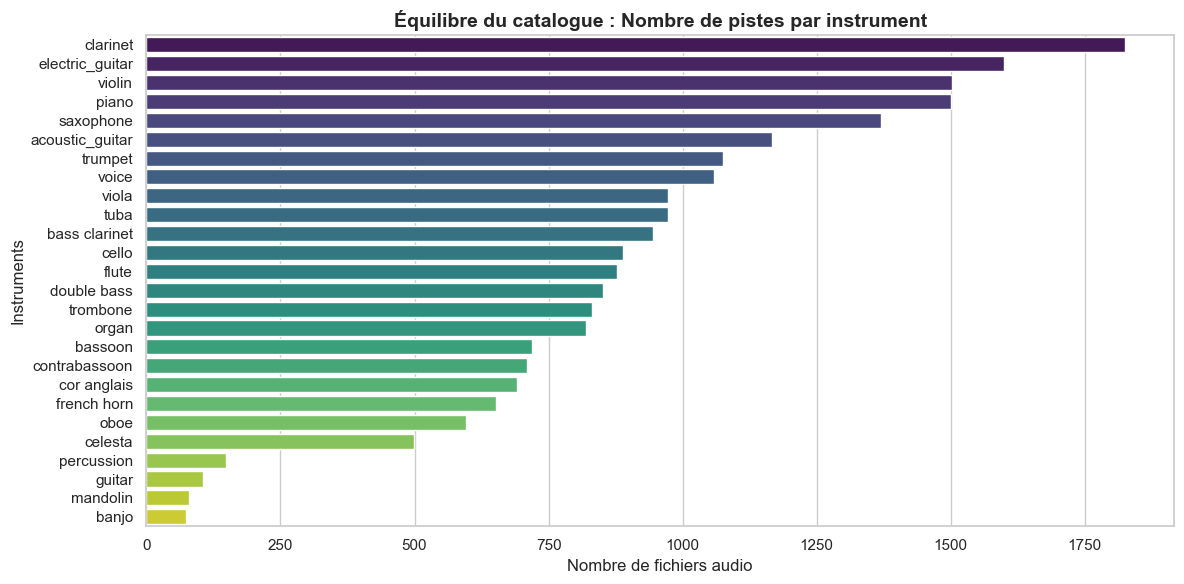

In [12]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


plt.figure()
sns.countplot(data=df_clean, y='instrument', order=df_clean['instrument'].value_counts().index, palette='viridis')
plt.title("Équilibre du catalogue : Nombre de pistes par instrument", fontsize=14, fontweight='bold')
plt.xlabel("Nombre de fichiers audio")
plt.ylabel("Instruments")
plt.tight_layout()
plt.show()

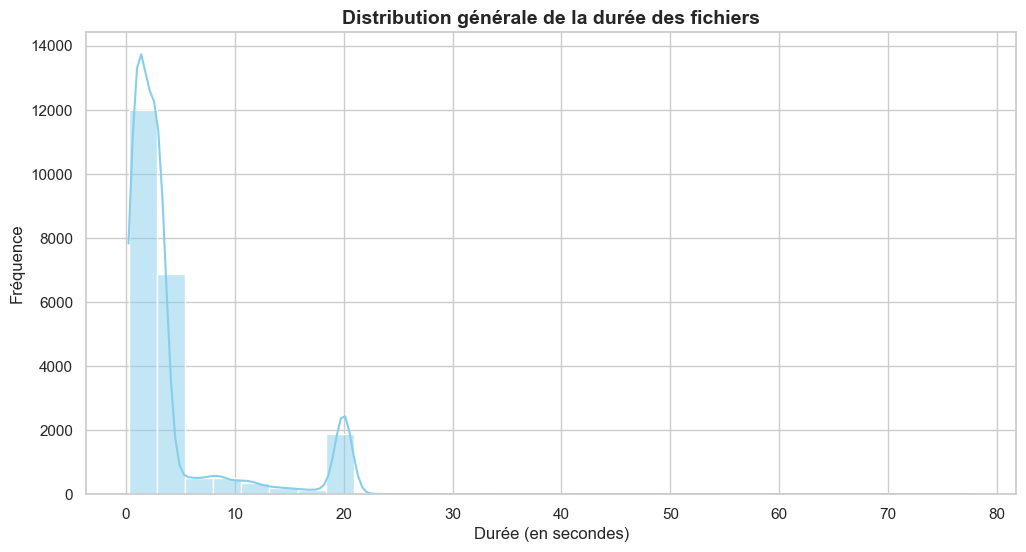

In [13]:
plt.figure()
sns.histplot(data=df_clean, x='duration_seconds', kde=True, bins=30, color='skyblue')
plt.title("Distribution générale de la durée des fichiers", fontsize=14, fontweight='bold')
plt.xlabel("Durée (en secondes)")
plt.ylabel("Fréquence")
plt.show()

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_10916\4258808779.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='instrument', y='duration_seconds', palette='Set2')


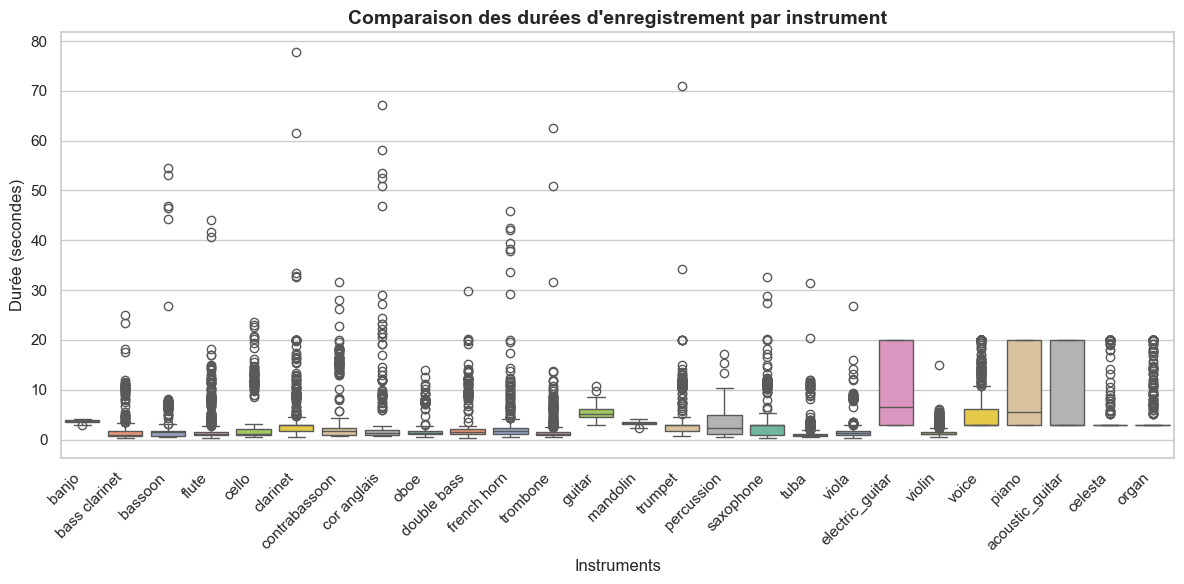

In [14]:
plt.figure()
sns.boxplot(data=df_clean, x='instrument', y='duration_seconds', palette='Set2')
plt.title("Comparaison des durées d'enregistrement par instrument", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Instruments")
plt.ylabel("Durée (secondes)")
plt.tight_layout()
plt.show()

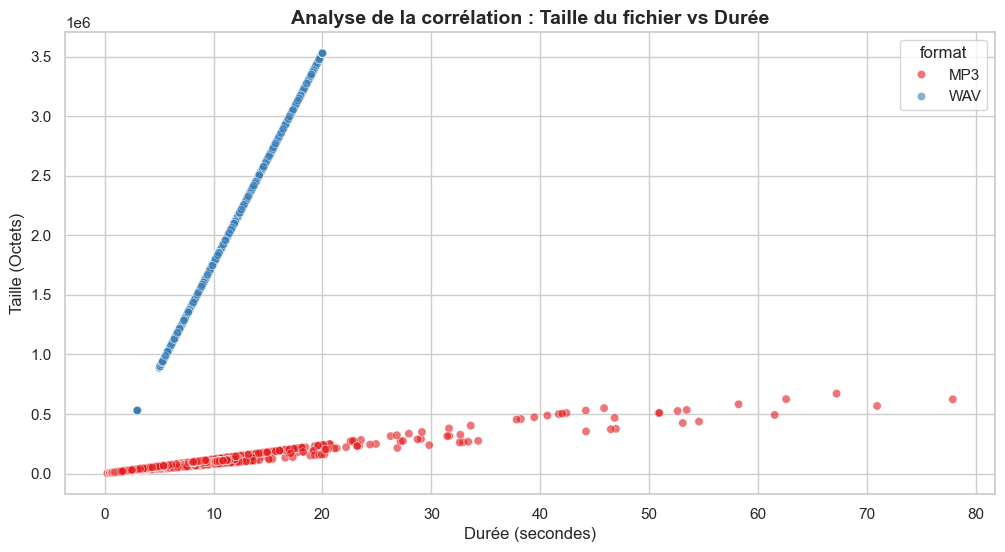

In [15]:
df_clean['format'] = df_clean['filename'].apply(lambda x: x.split('.')[-1].upper())

plt.figure()
sns.scatterplot(data=df_clean, x='duration_seconds', y='size_bytes', hue='format', alpha=0.6, palette='Set1')
plt.title("Analyse de la corrélation : Taille du fichier vs Durée", fontsize=14, fontweight='bold')
plt.xlabel("Durée (secondes)")
plt.ylabel("Taille (Octets)")
plt.show()

### Analyse multivariée

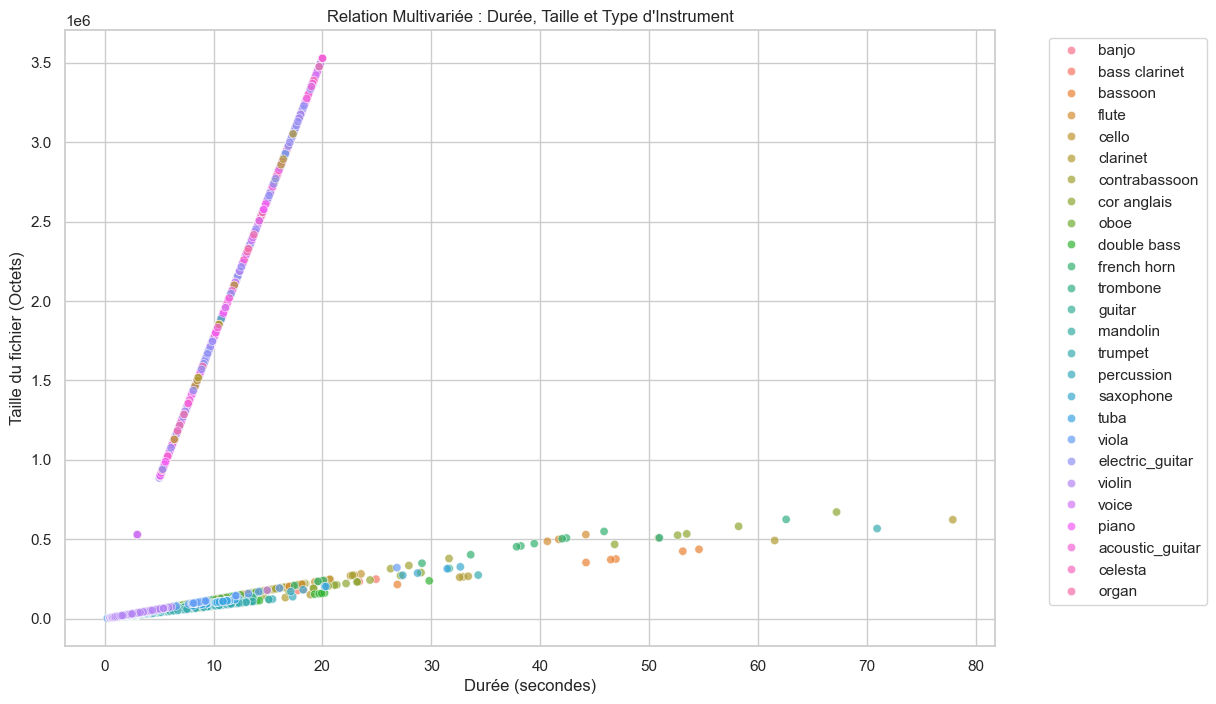

In [16]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_clean, 
    x='duration_seconds', 
    y='size_bytes', 
    hue='instrument', 
    alpha=0.7
)
plt.title("Relation Multivariée : Durée, Taille et Type d'Instrument")
plt.xlabel("Durée (secondes)")
plt.ylabel("Taille du fichier (Octets)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

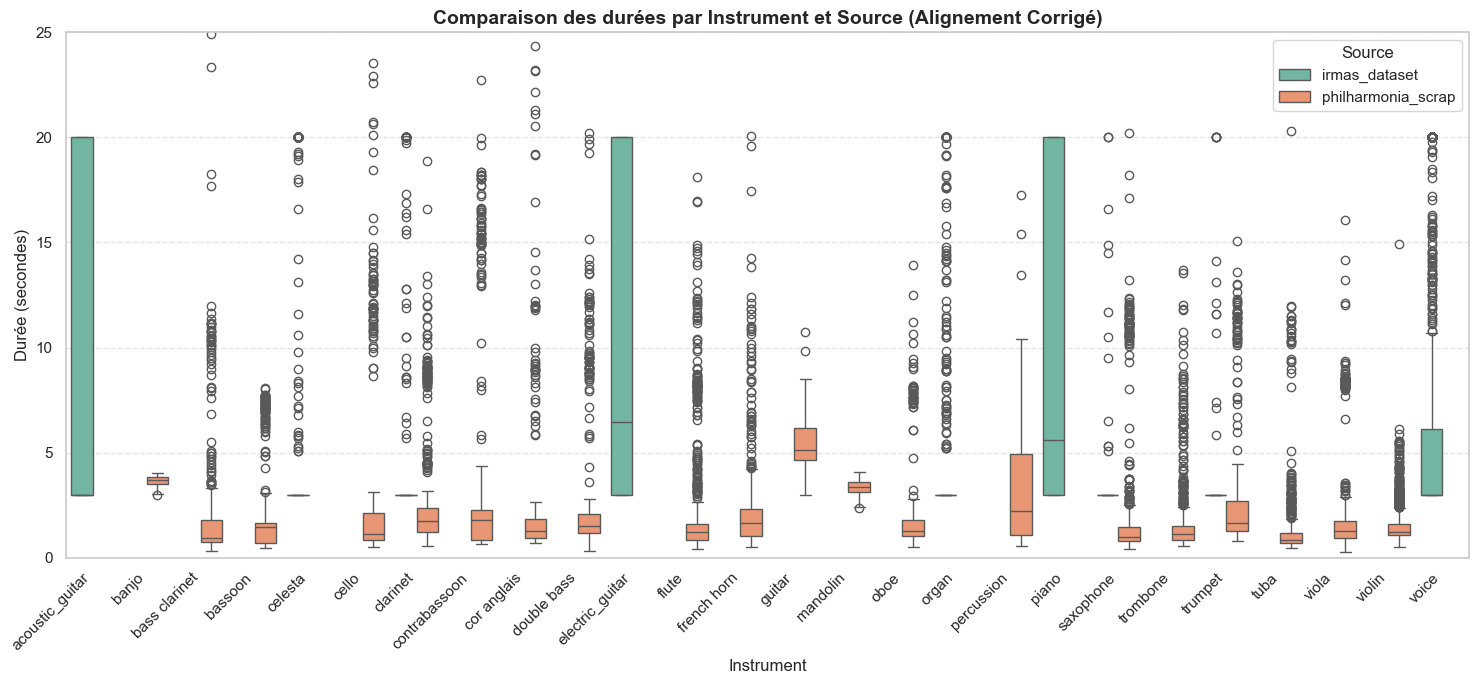

In [17]:
df_sorted = df_clean.sort_values(by='instrument')

plt.figure(figsize=(15, 7))

sns.boxplot(
    data=df_sorted, 
    x='instrument', 
    y='duration_seconds', 
    hue='source_dataset',
    palette='Set2',
    dodge=True, 
)

plt.ylim(0, 25)
plt.xticks(rotation=45, ha='right') 

plt.title("Comparaison des durées par Instrument et Source (Alignement Corrigé)", fontsize=14, fontweight='bold')
plt.xlabel("Instrument", fontsize=12)
plt.ylabel("Durée (secondes)", fontsize=12)
plt.legend(title="Source", loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

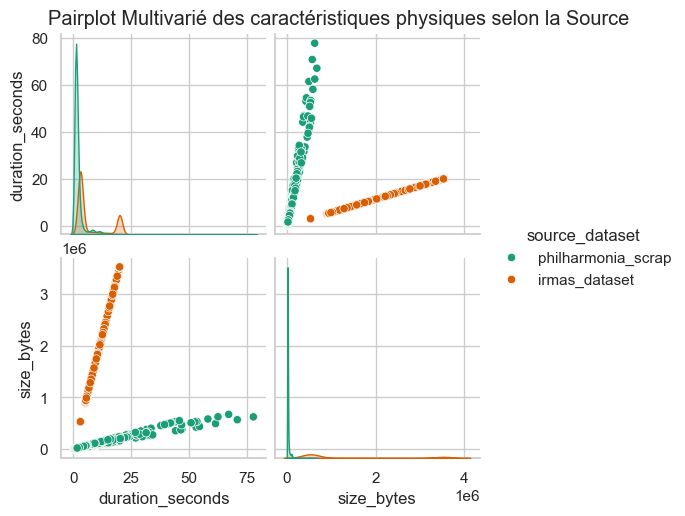

In [18]:
columns_to_plot = ['duration_seconds', 'size_bytes', 'source_dataset']

sns.pairplot(
    df_clean[columns_to_plot], 
    hue='source_dataset', 
    diag_kind='kde', 
    palette='Dark2'
)
plt.suptitle("Pairplot Multivarié des caractéristiques physiques selon la Source", y=1.02)
plt.show()

## Affichage des spectrogrammes

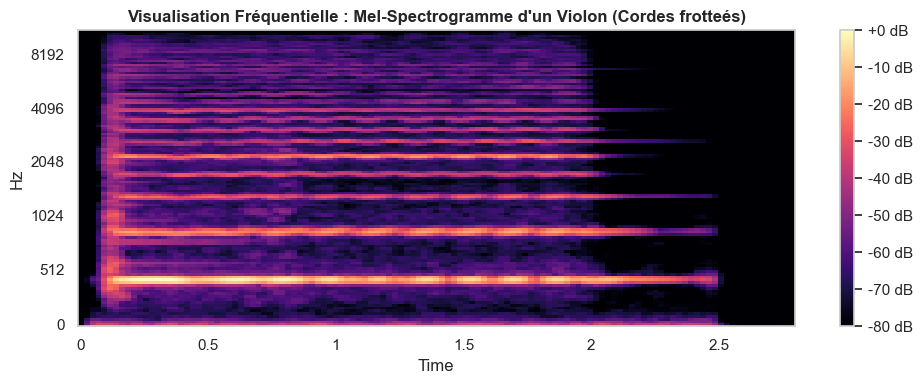

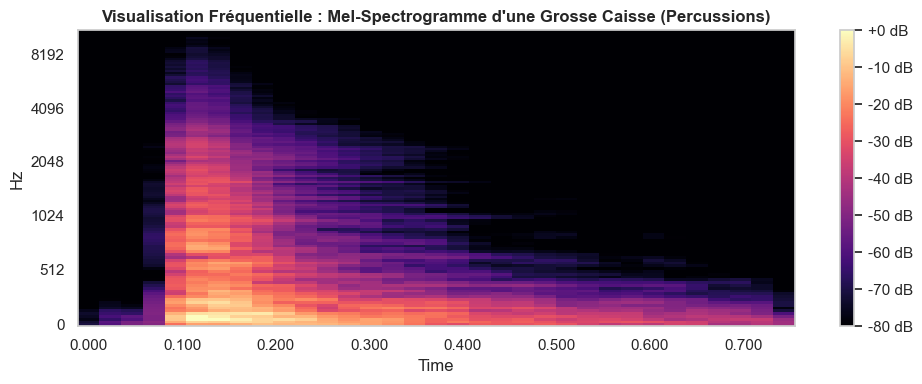

In [19]:
def plot_mel_spectrogram(file_path, title):
    """
    Charge un fichier audio, calcule son spectrogramme Mel et l'affiche sur une échelle en dB.

    Arguments:
        file_path (str): Le chemin d'accès local au fichier audio.
        title (str): Le titre du graphique.
        
    Retourne:
        None
    """
    try:
        y, sr = librosa.load(file_path)
        S = librosa.feature.melspectrogram(y=y, sr=sr)
        S_dB = librosa.power_to_db(S, ref=np.max)

        plt.figure(figsize=(10, 4))
        librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, cmap='magma')
        plt.colorbar(format='%+2.0f dB')
        plt.title(title, fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"⚠️ Impossible de générer le spectrogramme pour {file_path} : {e}")


plot_mel_spectrogram(
    "../data/scrap/philharmonia/violin/violin_A4_15_fortissimo_arco-normal.mp3",
    "Visualisation Fréquentielle : Mel-Spectrogramme d'un Violon (Cordes frotteés)"
)

plot_mel_spectrogram(
    "../data/scrap/philharmonia/percussion/bass-drum__025_forte_bass-drum-mallet.mp3",
    "Visualisation Fréquentielle : Mel-Spectrogramme d'une Grosse Caisse (Percussions)"
)

### Exemple de spectrogramme d'une percussion

## Analyse des 7 classes d'instruments

In [20]:
mapping_familles = {
    "organ": "orgues_et_claviers", "org": "orgues_et_claviers",
    "piano": "pianos_et_claviers", "celesta": "pianos_et_claviers","pia": "pianos_et_claviers",
    "acoustic_guitar": "cordes_pincees","gac": "cordes_pincees", "gel": "cordes_pincees", "electric_guitar": "cordes_pincees", "guitar": "cordes_pincees", "banjo": "cordes_pincees", "mandolin": "cordes_pincees",
    "cello": "cordes_frottees", "violin": "cordes_frottees", "viola": "cordes_frottees", "double bass": "cordes_frottees", "bassoon": "cordes_frottees", "contrabassoon": "cordes_frottees", "cel": "cordes_frottees", "vio": "cordes_frottees",
    "voice": "voix","voi": "voix",
    "percussion": "percussions",
    "bass clarinet": "vents_et_cuivres", "clarinet": "vents_et_cuivres", "flute": "vents_et_cuivres", "saxophone": "vents_et_cuivres", "trumpet": "vents_et_cuivres", "trombone": "vents_et_cuivres", "cor anglais": "vents_et_cuivres", "oboe": "vents_et_cuivres", "french horn": "vents_et_cuivres", "tuba": "vents_et_cuivres", "cla": "vents_et_cuivres", "flu": "vents_et_cuivres", "sax": "vents_et_cuivres", "tru": "vents_et_cuivres"
}

In [21]:
df_clean['famille_cible'] = df_clean['instrument'].map(mapping_familles)

df_clean['famille_cible'] = df_clean['famille_cible'].fillna("Instruments à Vent & Cuivres")

print("=== Distribution absolue et relative des 7 Familles Cibles ===")
distribution_familles = pd.DataFrame({
    'Nombre de pistes': df_clean['famille_cible'].value_counts(),
    'Proportion (%)': (df_clean['famille_cible'].value_counts(normalize=True) * 100).round(2)
})
display(distribution_familles)

=== Distribution absolue et relative des 7 Familles Cibles ===


,Nombre de pistes,Proportion (%)
famille_cible,,
vents_et_cuivres,9835,43.65
cordes_frottees,5646,25.06
cordes_pincees,3026,13.43
pianos_et_claviers,2000,8.88
voix,1059,4.70
orgues_et_claviers,819,3.63
percussions,148,0.66


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_10916\4054176243.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


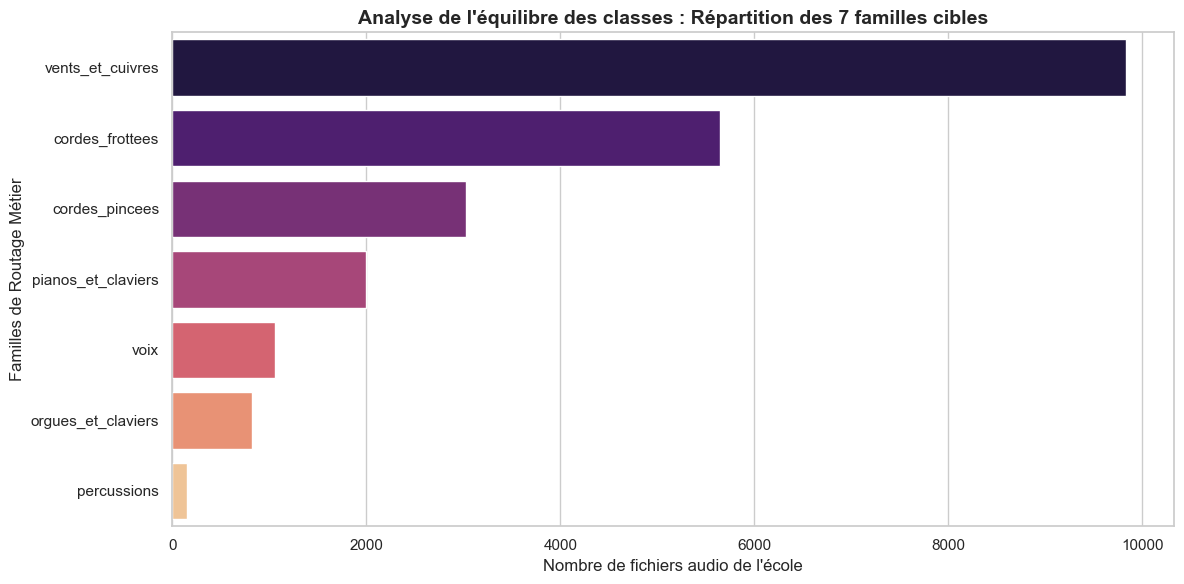

In [22]:
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_clean, 
    y='famille_cible', 
    order=df_clean['famille_cible'].value_counts().index, 
    palette='magma'
)
plt.title("Analyse de l'équilibre des classes : Répartition des 7 familles cibles", fontsize=14, fontweight='bold')
plt.xlabel("Nombre de fichiers audio de l'école")
plt.ylabel("Familles de Routage Métier")
plt.tight_layout()
plt.show()

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_10916\1622099914.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


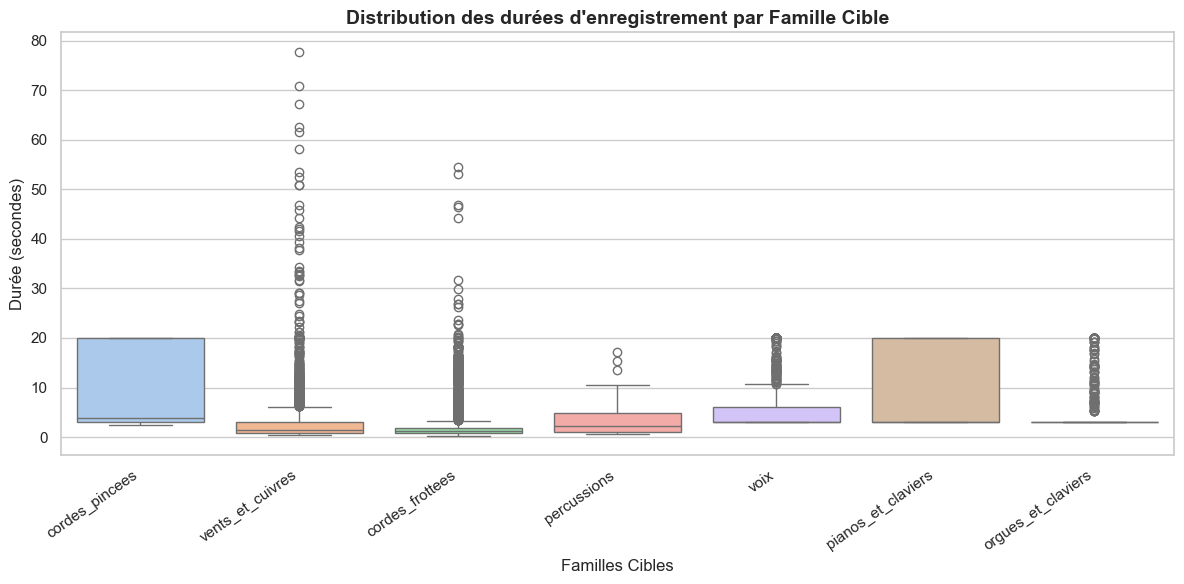

In [23]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_clean, 
    x='famille_cible', 
    y='duration_seconds', 
    palette='pastel'
)
plt.title("Distribution des durées d'enregistrement par Famille Cible", fontsize=14, fontweight='bold')
plt.xticks(rotation=35, ha='right')
plt.xlabel("Familles Cibles")
plt.ylabel("Durée (secondes)")
plt.tight_layout()
plt.show()

## Chromagramme et brillance spectrale

In [24]:
def generer_visualisations_acoustiques(chemin_fichier, nom_instrument):
    """
    Génère les graphiques d'analyse musicale pour un fichier donné :
    1. Le Chromagramme (distribution des notes de musique)
    2. La Brillance spectrale (fréquences dominantes)
    """
    try:
        y, sr = librosa.load(chemin_fichier, duration=3.0, sr=22050)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
        

        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        
        notes_musique = ['Do', 'Do#', 'Ré', 'Ré#', 'Mi', 'Fa', 'Fa#', 'Sol', 'Sol#', 'La', 'La#', 'Si']
        
        librosa.display.specshow(chroma, y_axis='chroma', x_axis='time', ax=ax1, cmap='magma')
        ax1.set_title(f"Répartition des Notes (Chromagramme) - {nom_instrument.upper()}", fontsize=12, fontweight='bold')
        ax1.set_ylabel("Notes de musique (Pitch Class)")
        ax1.set_xlabel("Temps (s)")

        ax1.set_yticks(np.arange(12))
        ax1.set_yticklabels(notes_musique)
        

        cents = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
        temps = librosa.times_like(cents, sr=sr)
        

        stft_spec = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
        librosa.display.specshow(stft_spec, y_axis='linear', x_axis='time', ax=ax2, cmap='coolwarm', alpha=0.6)
        

        ax2.plot(temps, cents, label='Centroïde Spectral (Centre de gravité)', color='black', lw=2, linestyle='--')
        ax2.set_title(f"Spectre de Fréquences & Brillance - {nom_instrument.upper()}", fontsize=12, fontweight='bold')
        ax2.set_ylabel("Fréquence (Hz)")
        ax2.set_xlabel("Temps (s)")
        ax2.set_ylim(0, 8000) 
        ax2.legend(loc='upper right')
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Impossible de générer les graphiques pour ce fichier : {e}")

Piste Gold détectée : banjo_As3_very-long_piano_normal.mp3
Classification cible : cordes_pincees (banjo)
Chemin local résolu : ../data\scrap\philharmonia\banjo\banjo_As3_very-long_piano_normal.mp3
Génération de l'analyse acoustique avancée...


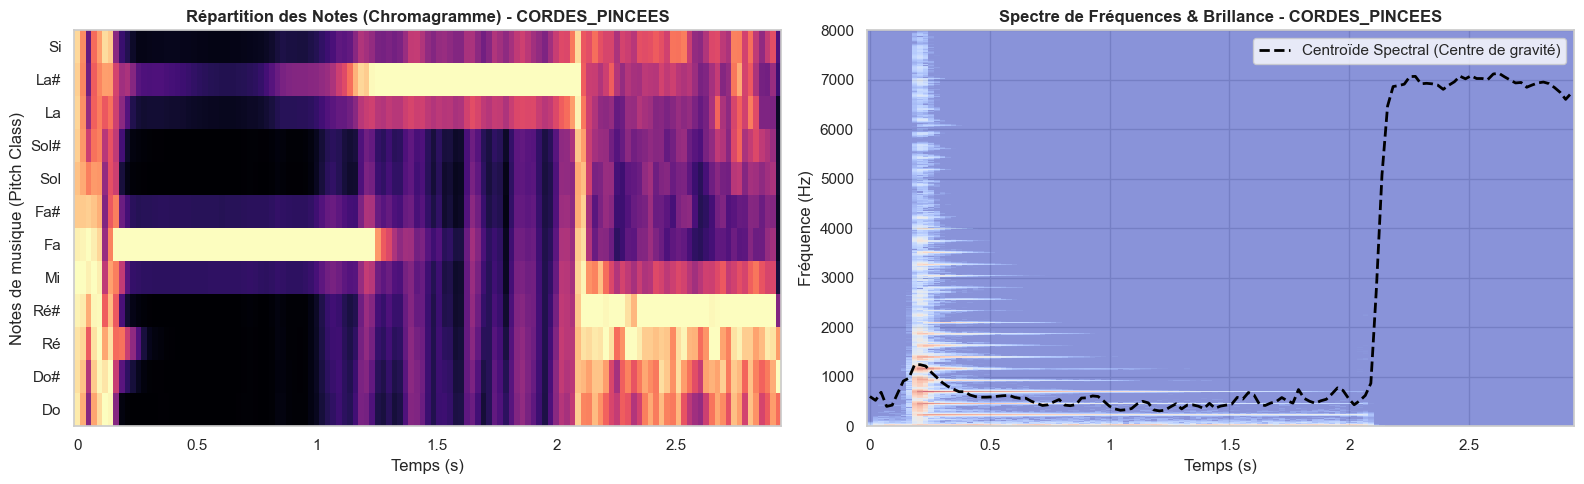

In [25]:
if len(df_clean) > 0:
    first_pist = df_clean.iloc[7]
    

    file_name = first_pist['filename']
    instrument_family = first_pist['famille_cible']
    instrument_name = first_pist['instrument']

    
    
    if "violin" in file_name or "bass-drum" in file_name or "acoustic" in file_name:
        path_demo = os.path.join("../data/scrap/philharmonia", instrument_name, file_name)
    else:
        path_demo = os.path.join("../data", instrument_name, file_name)
        
    if not os.path.exists(path_demo):
        import glob
        search = glob.glob(f"../data/**/{file_name}", recursive=True)
        if search:
            path_demo = search[0]

    print(f"Piste Gold détectée : {file_name}")
    print(f"Classification cible : {instrument_family} ({instrument_name})")
    print(f"Chemin local résolu : {path_demo}")
    

    print("Génération de l'analyse acoustique avancée...")
    generer_visualisations_acoustiques(path_demo, instrument_family)
else:
    print("Le DataFrame PostgreSQL Gold est vide. Impossible de générer l'analyse.")

Piste Gold détectée : cello_G2_15_mezzo-piano_arco-normal.mp3
Classification cible : cordes_frottees (cello)
Chemin local résolu : ../data\scrap\philharmonia\cello\cello_G2_15_mezzo-piano_arco-normal.mp3
Génération de l'analyse acoustique avancée...


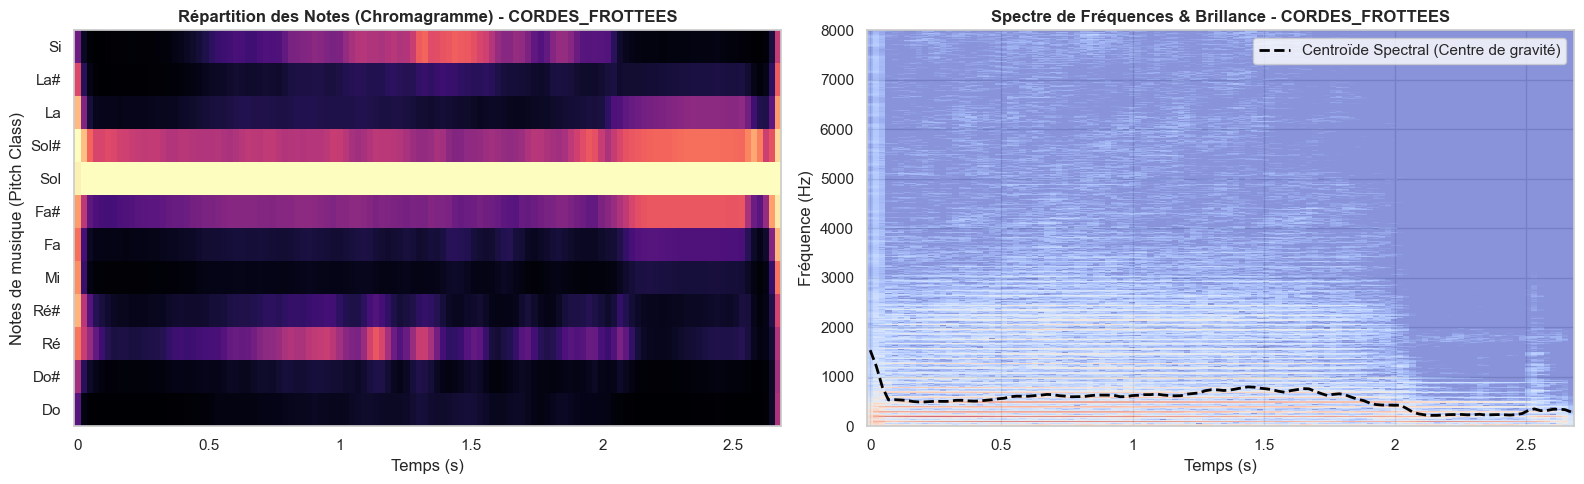

In [26]:
if len(df_clean) > 0:
    scd_pist = df_clean.iloc[2500]    
    file_name2 = scd_pist['filename']
    instrument_family2 = scd_pist['famille_cible']
    instrument_name2 = scd_pist['instrument']


    if "violin" in file_name2 or "bass-drum" in file_name2 or "acoustic" in file_name2:
        path_demo = os.path.join("../data/scrap/philharmonia", instrument_name, file_name2)
    else:
        path_demo = os.path.join("../data", instrument_name, file_name2)
        
    if not os.path.exists(path_demo):
        import glob
        search = glob.glob(f"../data/**/{file_name2}", recursive=True)
        if search:
            path_demo = search[0]

    print(f"Piste Gold détectée : {file_name2}")
    print(f"Classification cible : {instrument_family2} ({instrument_name2})")
    print(f"Chemin local résolu : {path_demo}")
    

    print("Génération de l'analyse acoustique avancée...")
    generer_visualisations_acoustiques(path_demo, instrument_family2)
else:
    print("Le DataFrame PostgreSQL Gold est vide. Impossible de générer l'analyse.")